Checking language type distribution in existing pretraining corpora

In [1]:
import os
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from huggingface_hub import HfApi, hf_hub_download

tqdm.pandas()

lang = "rwo"

FONT_SIZES = {"small": 14, "medium": 18, "large": 24}

PLOT_PARAMS = {
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": FONT_SIZES.get("medium"),
    "axes.titlesize": FONT_SIZES.get("large"),
    "axes.labelsize": FONT_SIZES.get("large"),
    "xtick.labelsize": FONT_SIZES.get("large"),
    "ytick.labelsize": FONT_SIZES.get("large"),
    "legend.fontsize": FONT_SIZES.get("medium"),
    "figure.titlesize": FONT_SIZES.get("medium"),
    "text.usetex": True,
}

plt.rcParams.update(PLOT_PARAMS)

/Users/ljvmiranda/Developer/scratch/2026-03-20-madlad/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_madlad(lang: str, split: str = "clean_docs") -> pd.DataFrame:
    """Load MADLAD-400 data for a given language code into a DataFrame.

    Args:
        lang: Language code (e.g. 'ceb', 'tgl', 'en').
        split: Which split to load — 'clean_docs', 'noisy_docs', or 'all'.
    """
    api = HfApi()
    files = api.list_repo_tree(
        "allenai/MADLAD-400",
        path_in_repo=f"data-v1p5/{lang}",
        repo_type="dataset",
    )

    local_dir = f"data/{lang}"
    os.makedirs(local_dir, exist_ok=True)

    paths = []
    for f in files:
        if not f.rfilename.endswith(".jsonl.gz"):
            continue
        if split != "all" and split not in f.rfilename:
            continue
        path = hf_hub_download(
            "allenai/MADLAD-400",
            filename=f.rfilename,
            repo_type="dataset",
            local_dir=local_dir,
        )
        paths.append(path)

    print(f"Downloaded {len(paths)} files for '{lang}'")
    return pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True)

In [3]:
df = load_madlad(lang, split="clean_docs")
df.head(5)

Downloaded 5 files for 'rwo'


,text,timestamp,url
0,Mat 5 | `RWOKARO | STEP | Yesus oni simoo bale...,2018-09-20 06:31:15+00:00,https://www.stepbible.org/?q=version=RWOKARO%7...
1,Gal 6 | `RWORAWA | STEP | Ye Kristen dobookuri...,2018-09-24 03:36:12+00:00,https://www.stepbible.org/?q=version=RWORAWA%7...
2,Act 15 | `RWOKARO | STEP | Ene Yuda oni gidale...,2018-09-23 23:57:33+00:00,https://www.stepbible.org/?q=version=RWOKARO%7...
3,Tit 3 | `RWOKARO | STEP | Ge komo nalu bidodom...,2018-09-26 14:17:41+00:00,https://www.stepbible.org/?q=version=RWOKARO%7...
4,"Rom 5 | `RWORAWA | STEP | Arisa, noore Yisasro...",2018-09-19 14:27:27+00:00,https://www.stepbible.org/?q=version=RWORAWA%7...


In [4]:
df.iloc[0].text

'Mat 5 | `RWOKARO | STEP | Yesus oni simoo bale oowooyingga oolengo yeyolo ngu, ene mela puli sanganimo oolelo, bibitetoni, enengo sulena oniku, eneno oolewolo.\\naKisim Bek/Eksodas 20:13\\n11 Ngundilo nangge, ye no kenelootoyi, ngulo melako oni, ngando kootuyesina mande biyomi elo kowuli oowooyingga yunolo, kingo mande ebe ganagana etoyi ngu, ngulo ye nowoondoye kowuli ma ingowelo. Kini, ye komo oni oni teya, nowoondoye imakeyingomo ootooya, Anut oowooyi bingami eya okooya, oni oni teyi. Ndatelo ngulo, ye Sambo endemo oo ulungga ngu yowanggo. Ngundilo nangge, melako onindo Anutlo ingondudu eyingo oni nguya koletelo yombulibaliyelowonggorilo ewolo.\\nYe oni ma uleyi kumoowelo. Ene ge oni uleyi kumoowaku ngu, asa, ge mande wilikoyingo onino oolelo, nguno gumi ulungga yowalo ewolo. a\\n23 Ge Anutno yambo mande tewelo ingolo, ngulo ge eneno kingo oo duwoo yewelo uya ngu, doboogebo geya biyomi ingooteku ingolo ngu, asa, koletelo ge eneno oolouya, biyomingga ngu andangeya, yomosiyoyago, koo

Before we do some fun stuff, might be nice to just learn more about the data

In [5]:
enc = tiktoken.get_encoding("cl100k_base")
df["token_length"] = df["text"].progress_apply(lambda x: len(enc.encode(x)))

100%|██████████| 292/292 [00:00<00:00, 1922.72it/s]


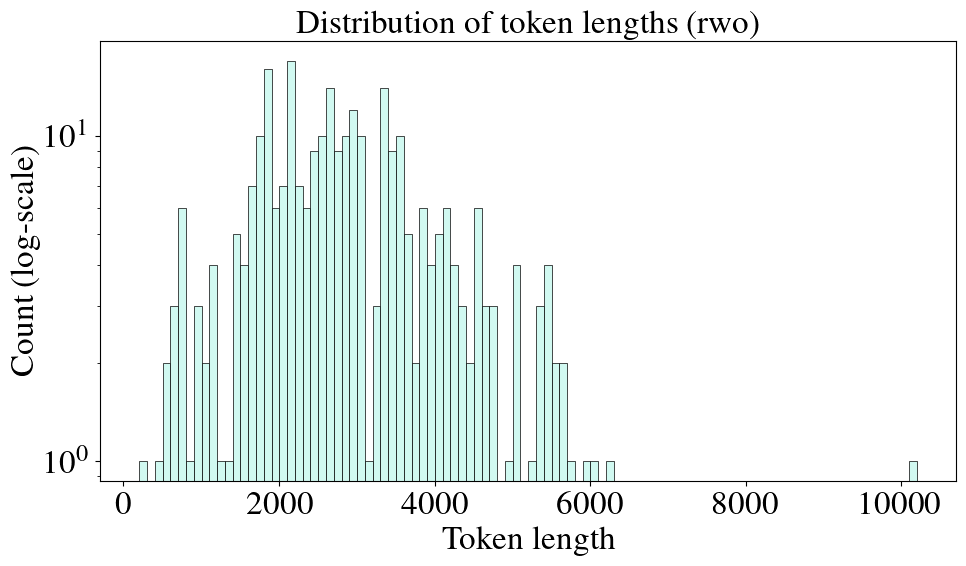

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["token_length"], bins=100, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.set_yscale("log")
ax.set_xlabel("Token length")
ax.set_ylabel("Count (log-scale)")
ax.set_title(f"Distribution of token lengths ({lang})")
fig.tight_layout()
plt.show()

Ideally, I'd check each text and confirm which data type they have. But assuming I don't have any knowledge about the language, what can I do? Maybe...

- Check the URLs? Perhaps there's a way to cross-reference URLs to a certain domain.
- Use an LLM? Maybe something like [this work](https://arxiv.org/pdf/2502.10341). But how do you validate this?

Let's start by checking the URLs

In [7]:
from urllib.parse import urlparse

df["tld"] = df["url"].apply(lambda x: "." + urlparse(x).netloc.rsplit(".", 1)[-1])

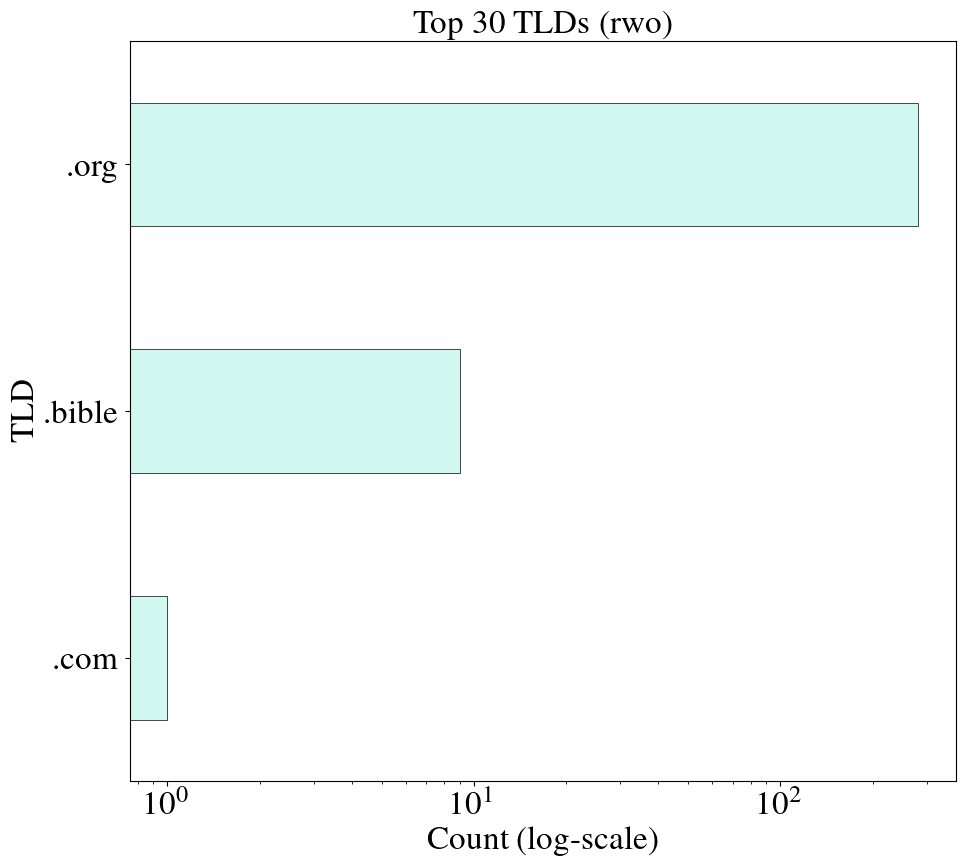

In [8]:
top_n = 30
tld_counts = df["tld"].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(10, 9))
tld_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Count (log-scale)")
ax.set_ylabel("TLD")
ax.set_title(f"Top {top_n} TLDs ({lang})")
fig.tight_layout()
plt.show()

### Topic classification

Using [WebOrganizer/TopicClassifier](https://huggingface.co/WebOrganizer/TopicClassifier) to classify documents into 24 topic categories.

In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

TOPIC_LABELS = {
    0: "Adult",
    1: "Art & Design",
    2: "Software Dev.",
    3: "Crime & Law",
    4: "Education & Jobs",
    5: "Hardware",
    6: "Entertainment",
    7: "Social Life",
    8: "Fashion & Beauty",
    9: "Finance & Business",
    10: "Food & Dining",
    11: "Games",
    12: "Health",
    13: "History",
    14: "Home & Hobbies",
    15: "Industrial",
    16: "Literature",
    17: "Politics",
    18: "Religion",
    19: "Science & Tech.",
    20: "Software",
    21: "Sports & Fitness",
    22: "Transportation",
    23: "Travel",
}

device = torch.device("cpu")

topic_tokenizer = AutoTokenizer.from_pretrained("WebOrganizer/TopicClassifier")
topic_model = (
    AutoModelForSequenceClassification.from_pretrained(
        "WebOrganizer/TopicClassifier",
        trust_remote_code=True,
        use_memory_efficient_attention=False,
        torch_dtype=torch.float32,
    )
    .to(device)
    .eval()
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 139/139 [00:00<00:00, 26306.66it/s]


In [10]:
@torch.no_grad()
def classify_topic(text: str, url: str = "") -> str:
    """Classify a single document into one of 24 topic categories."""
    input_text = f"{url}\n\n{text}" if url else text
    inputs = topic_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    seq_len = inputs["input_ids"].shape[1]
    inputs["position_ids"] = torch.arange(
        seq_len, dtype=torch.long, device=device
    ).unsqueeze(0)
    outputs = topic_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return TOPIC_LABELS[pred]


# Quick test
print("{url}\nn{text}".format(url=df["url"].iloc[0], text=df["text"].iloc[0]))
classify_topic(df["text"].iloc[0], df["url"].iloc[0])

https://www.stepbible.org/?q=version=RWOKARO%7Creference=Mat.5
nMat 5 | `RWOKARO | STEP | Yesus oni simoo bale oowooyingga oolengo yeyolo ngu, ene mela puli sanganimo oolelo, bibitetoni, enengo sulena oniku, eneno oolewolo.\naKisim Bek/Eksodas 20:13\n11 Ngundilo nangge, ye no kenelootoyi, ngulo melako oni, ngando kootuyesina mande biyomi elo kowuli oowooyingga yunolo, kingo mande ebe ganagana etoyi ngu, ngulo ye nowoondoye kowuli ma ingowelo. Kini, ye komo oni oni teya, nowoondoye imakeyingomo ootooya, Anut oowooyi bingami eya okooya, oni oni teyi. Ndatelo ngulo, ye Sambo endemo oo ulungga ngu yowanggo. Ngundilo nangge, melako onindo Anutlo ingondudu eyingo oni nguya koletelo yombulibaliyelowonggorilo ewolo.\nYe oni ma uleyi kumoowelo. Ene ge oni uleyi kumoowaku ngu, asa, ge mande wilikoyingo onino oolelo, nguno gumi ulungga yowalo ewolo. a\n23 Ge Anutno yambo mande tewelo ingolo, ngulo ge eneno kingo oo duwoo yewelo uya ngu, doboogebo geya biyomi ingooteku ingolo ngu, asa, koletelo ge

'Adult'

In [11]:
df_sample = df.sample(100)
df_sample["topic"] = df_sample.progress_apply(
    lambda row: classify_topic(row["text"], row["url"]), axis=1
)

100%|██████████| 100/100 [01:12<00:00,  1.38it/s]


In [12]:
import textwrap


def inspect_topic(df: pd.DataFrame, topic: str, n: int = 5) -> pd.DataFrame:
    """Sample n rows from a given topic and display text snippets."""
    subset = df[df["topic"] == topic]
    sample = subset.sample(min(n, len(subset)))
    for _, row in sample.iterrows():
        print(f"[{row['topic']}] {row['url']}")
        print(textwrap.fill(row["text"][:300], width=70))
        print("---")
    return sample


inspect_topic(df_sample, "Finance & Business", n=5)

,text,timestamp,url,token_length,tld,topic


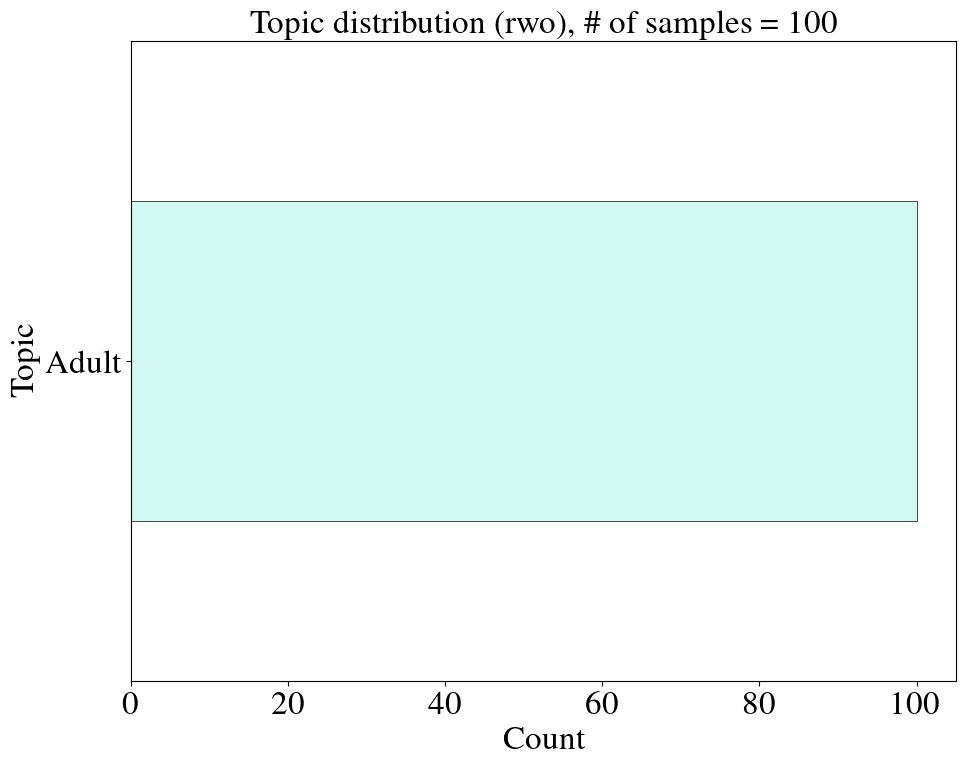

In [13]:
topic_counts = df_sample["topic"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
topic_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_yticklabels([label.replace("&", r"\&") for label in topic_counts.index])
ax.set_xlabel("Count")
ax.set_ylabel("Topic")
ax.set_title(f"Topic distribution ({lang}), \\# of samples = {len(df_sample)}")
fig.tight_layout()
plt.show()

### Format classification

Using [WebOrganizer/FormatClassifier](https://huggingface.co/WebOrganizer/FormatClassifier) to classify documents into 24 format categories.

In [14]:
FORMAT_LABELS = {
    0: "Academic Writing",
    1: "Content Listing",
    2: "Creative Writing",
    3: "Customer Support",
    4: "Comment Section",
    5: "FAQ",
    6: "Truncated",
    7: "Knowledge Article",
    8: "Legal Notices",
    9: "Listicle",
    10: "News Article",
    11: "Nonfiction Writing",
    12: "About (Org.)",
    13: "News (Org.)",
    14: "About (Pers.)",
    15: "Personal Blog",
    16: "Product Page",
    17: "Q&A Forum",
    18: "Spam / Ads",
    19: "Structured Data",
    20: "Documentation",
    21: "Audio Transcript",
    22: "Tutorial",
    23: "User Review",
}

format_tokenizer = AutoTokenizer.from_pretrained("WebOrganizer/FormatClassifier")
format_model = (
    AutoModelForSequenceClassification.from_pretrained(
        "WebOrganizer/FormatClassifier",
        trust_remote_code=True,
        use_memory_efficient_attention=False,
        torch_dtype=torch.float32,
    )
    .to(device)
    .eval()
)

Loading weights: 100%|██████████| 139/139 [00:00<00:00, 23483.78it/s]


In [15]:
@torch.no_grad()
def classify_format(text: str, url: str = "") -> str:
    """Classify a single document into one of 24 format categories."""
    input_text = f"{url}\n\n{text}" if url else text
    inputs = format_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    seq_len = inputs["input_ids"].shape[1]
    inputs["position_ids"] = torch.arange(
        seq_len, dtype=torch.long, device=device
    ).unsqueeze(0)
    outputs = format_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return FORMAT_LABELS[pred]


# Quick test
classify_format(df["text"].iloc[0], df["url"].iloc[0])

'Academic Writing'

In [16]:
df_sample["format"] = df_sample.progress_apply(
    lambda row: classify_format(row["text"], row["url"]), axis=1
)

100%|██████████| 100/100 [01:13<00:00,  1.35it/s]


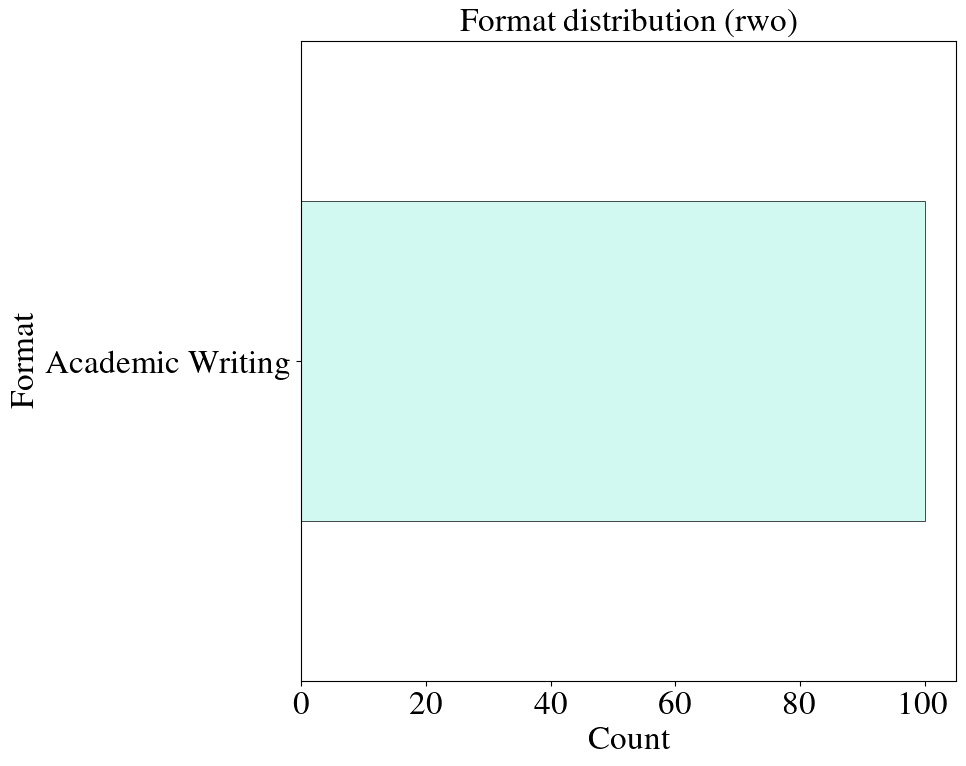

In [17]:
format_counts = df_sample["format"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
format_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_yticklabels([label.replace("&", r"\&") for label in format_counts.index])
ax.set_xlabel("Count")
ax.set_ylabel("Format")
ax.set_title(f"Format distribution ({lang})")
fig.tight_layout()
plt.show()

In [18]:
@torch.no_grad()
def classify_topic(text: str, url: str = "") -> str:
    input_text = f"{url}\n\n{text}" if url else text
    inputs = topic_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    outputs = topic_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return TOPIC_LABELS[pred]


# Quick test
classify_topic(df["text"].iloc[0], df["url"].iloc[0])

IndexError: index 10519314432 is out of bounds for dimension 0 with size 834

In [ ]:
def inspect_format(df: pd.DataFrame, fmt: str, n: int = 5) -> pd.DataFrame:
    """Sample n rows from a given format and display text snippets."""
    subset = df[df["format"] == fmt]
    sample = subset.sample(min(n, len(subset)))
    for _, row in sample.iterrows():
        print(f"[{row['format']}] {row['url']}")
        print(textwrap.fill(row["text"][:300], width=70))
        print("---")
    return sample


inspect_format(df_sample, "News Article", n=3)

### Embeddings and keyword extraction

Using [intfloat/multilingual-e5-large](https://huggingface.co/intfloat/multilingual-e5-large) for multilingual embeddings and [KeyBERT](https://github.com/MaartenGr/KeyBERT) for keyword extraction. UMAP for dimensionality reduction.

In [19]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("intfloat/multilingual-e5-large")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 9263.19it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
import numpy as np

df_sample_emb = df.sample(250)
# multilingual-e5 expects "query: " or "passage: " prefix
texts = ["passage: " + t for t in df_sample_emb["text"].tolist()]
embeddings = embed_model.encode(texts, show_progress_bar=True, batch_size=16)
embeddings = np.array(embeddings)

Batches: 100%|██████████| 16/16 [00:20<00:00,  1.30s/it]


In [23]:
from umap import UMAP
from sklearn.cluster import HDBSCAN

reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords = reducer.fit_transform(embeddings)
df_sample_emb["umap_x"] = coords[:, 0]
df_sample_emb["umap_y"] = coords[:, 1]

clusterer = HDBSCAN(min_cluster_size=5)
df_sample_emb["cluster"] = clusterer.fit_predict(coords)

/Users/ljvmiranda/Developer/scratch/2026-03-20-madlad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ljvmiranda/Developer/scratch/2026-03-20-madlad/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [26]:
from keybert import KeyBERT

kw_model = KeyBERT(model=embed_model)

df_sample_emb["keywords"] = df_sample_emb["text"].progress_apply(
    lambda t: [kw for kw, _ in kw_model.extract_keywords(t, top_n=5)]
)

  9%|▉         | 23/250 [00:13<01:35,  2.37it/s]

In [30]:
def inspect_cluster(df: pd.DataFrame, cluster_id: int, n: int = 5) -> pd.DataFrame:
    """Sample rows from a cluster and show keywords + text snippet."""
    subset = df[df["cluster"] == cluster_id]
    sample = subset.sample(min(n, len(subset)))
    for _, row in sample.iterrows():
        print(f"[cluster {row['cluster']}] {row['url']}")
        print(f"Keywords: {', '.join(row['keywords'])}")
        print(textwrap.fill(row["text"][:200], width=70))
        print("---")
    return sample


inspect_cluster(df_sample_emb, cluster_id=0, n=3)

[cluster 0] https://ebible.org/study/content/texts/rwo-karo/MT19.html
Keywords: toongoowelolo, yesusnolo, tewoongowelo, yesusndo, yowoolengolo
﻿ Anutlo Sumange Mande Keda Matiyu 19\nYesusndo Elambalisa
Toongooweloyi Damoni, Ngulo Etuyelowolo\n1 Ngu naluno, Yesus mande
kinitetoni ngu, ene Galili mela yokolo, ene Yudiya mela Yodan sono
andulok
---
[cluster 0] https://ebible.org/study/content/texts/rwo-karo/EP5.html
Keywords: kenomayingolo, anutlo, endeyolo, kenomayingoweloyi, endeyowelo
﻿ Anutlo Sumange Mande Keda Epesas 5\n☰ Epesas 5 ◀ ▶\nNoole Komo Solu
Himimo Endeyowato\n1 Anutndo ngu ye, enengo simoongo, ngulo gome
oolengo ingoote. Ngulo ye Anut kilalongo oliyi. Yo, ye komo eneng
---
[cluster 0] https://ebible.org/study/content/texts/rwo-karo/GL5.html
Keywords: kenomayingoweloyi, kenomayingolo, kristusndo, etuyelootenggoku, doongooweloyi
﻿ Anutlo Sumange Mande Keda Galesiya 5\n☰ Galesiya 5 ◀ ▶\nNoole Mamana
Mande Newendemo Ko Ma Oolooteto Kini, Noole Kristusno Keda
Oolooteto\n1 Krist

,text,timestamp,url,token_length,tld,umap_x,umap_y,cluster,keywords
274,﻿ Anutlo Sumange Mande Keda Matiyu 19\nYesusnd...,2019-04-25 00:41:17+00:00,https://ebible.org/study/content/texts/rwo-kar...,3003,.org,0.466020,-1.838070,0,"[toongoowelolo, yesusnolo, tewoongowelo, yesus..."
67,﻿ Anutlo Sumange Mande Keda Epesas 5\n☰ Epesas...,2019-04-22 06:14:51+00:00,https://ebible.org/study/content/texts/rwo-kar...,2518,.org,-0.054845,-2.695453,0,"[kenomayingolo, anutlo, endeyolo, kenomayingow..."
239,﻿ Anutlo Sumange Mande Keda Galesiya 5\n☰ Gale...,2019-09-22 05:38:41+00:00,https://ebible.org/study/content/texts/rwo-kar...,2600,.org,0.057754,-2.401139,0,"[kenomayingoweloyi, kenomayingolo, kristusndo,..."


In [31]:
from collections import Counter

# Get top keywords per cluster
cluster_labels = {}
for cid in sorted(df_sample_emb["cluster"].unique()):
    if cid == -1:
        continue
    all_kws = df_sample_emb[df_sample_emb["cluster"] == cid]["keywords"].explode()
    top_kws = [kw for kw, _ in Counter(all_kws).most_common(3)]
    cluster_labels[cid] = ", ".join(top_kws)

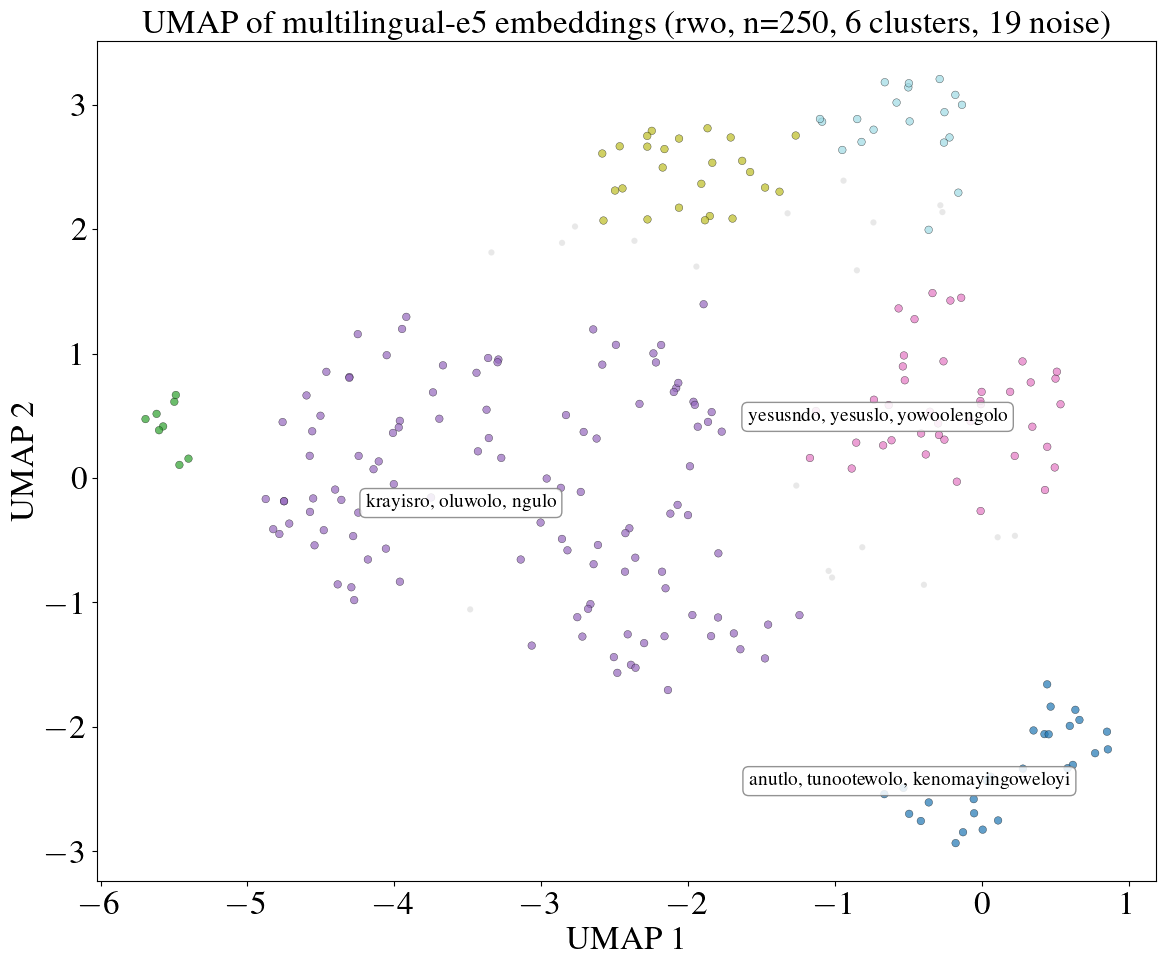

In [32]:
from adjustText import adjust_text

n_clusters = df_sample_emb["cluster"].nunique() - (
    1 if -1 in df_sample_emb["cluster"].values else 0
)
n_noise = (df_sample_emb["cluster"] == -1).sum()

cluster_sizes = df_sample_emb[df_sample_emb["cluster"] != -1]["cluster"].value_counts()
size_threshold = cluster_sizes.median()
major_clusters = cluster_sizes[cluster_sizes >= size_threshold].index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))

noise = df_sample_emb[df_sample_emb["cluster"] == -1]
ax.scatter(
    noise["umap_x"], noise["umap_y"], c="lightgray", s=20, alpha=0.5, edgecolors="none"
)

clustered = df_sample_emb[df_sample_emb["cluster"] != -1]
sc = ax.scatter(
    clustered["umap_x"],
    clustered["umap_y"],
    c=clustered["cluster"],
    cmap="tab20",
    s=30,
    alpha=0.7,
    edgecolors="black",
    linewidth=0.3,
)

texts = []
for cid in major_clusters:
    if cid not in cluster_labels:
        continue
    mask = df_sample_emb["cluster"] == cid
    cx = df_sample_emb.loc[mask, "umap_x"].mean()
    cy = df_sample_emb.loc[mask, "umap_y"].mean()
    label_esc = cluster_labels[cid].replace("&", r"\&")
    t = ax.text(
        cx,
        cy,
        label_esc,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85),
    )
    texts.append(t)

adjust_text(texts, ax=ax)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title(
    f"UMAP of multilingual-e5 embeddings ({lang}, n={len(df_sample_emb)}, {n_clusters} clusters, {n_noise} noise)"
)
fig.tight_layout()
plt.show()